<a href="https://colab.research.google.com/github/miriam-silva/amt4-s1a2026/blob/main/MultiNeural(Census)Tarefa0906.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes| Digest GaussianNB [Fase 1 - census]

## Importar dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [3]:
!pip -q install plotly
!pip -q install yellowbrick

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census


In [5]:
import pickle

In [6]:
with open('/content/drive/MyDrive/AprendizagemDeMaquinaIcoma/am-t4/census.pkl', 'rb') as f:
 X_census_trainamento,Y_census_trainamento,X_census_teste,Y_census_teste = pickle.load(f)

In [7]:
X_census_trainamento.shape ,Y_census_trainamento.shape

((27676, 108), (27676,))

In [8]:
X_census_teste.shape ,Y_census_teste.shape

((4885, 108), (4885,))

In [9]:
from sklearn.naive_bayes import GaussianNB

In [10]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_trainamento,Y_census_trainamento)

GaussianNB()

## Criando base Previsora


In [11]:
census_predict = naive_census_data.predict(X_census_teste)

In [12]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [13]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [16]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [17]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

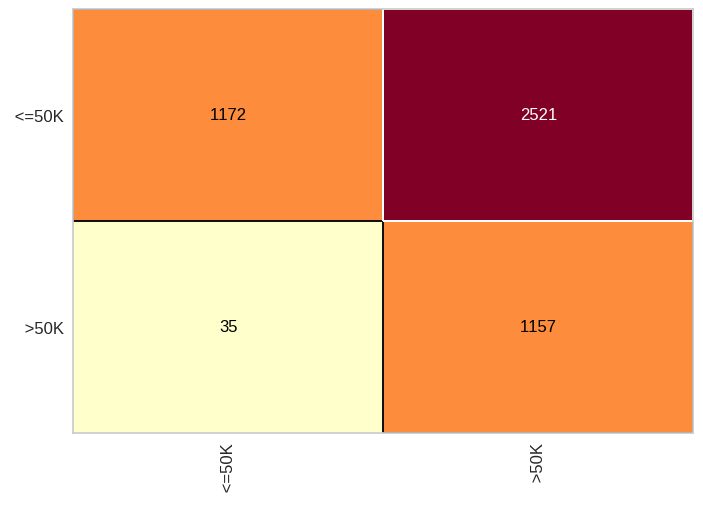

In [18]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)


# Pipeline Árvore de Decisão | Treemap Base [Fase 2 - census]

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_trainamento,Y_census_trainamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [21]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='better')

DecisionTreeClassifier(criterion='entropy', random_state=0, splitter='better')

In [22]:
previsao_arvore_census = arvore_census_data.predict(X_census_teste)

In [23]:
previsao_arvore_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [24]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

# Pipeline Medições Harmônicas | Treemap Base [Fase 3 - credit_data]

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
accuracy_score(Y_census_teste, previsao_arvore_census)

0.8104401228249745

0.8104401228249745

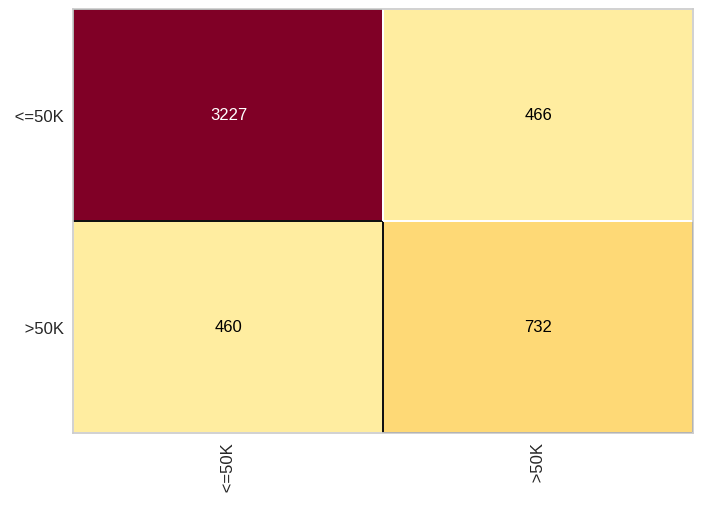

In [27]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(arvore_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)

In [28]:
print(classification_report(Y_census_teste, previsao_arvore_census))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Pipeline Random Forest | Digest Dados [Fase 4 - Census_Base]

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_trainamento, Y_census_trainamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion="entropy", max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [31]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [34]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [35]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 5 - Census_Base]

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_trainamento, Y_census_trainamento)

LogisticRegression(random_state=1)

In [38]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='12',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', penalty='12', random_state=1)

In [39]:
previsores_regressao = regressao_census.predict(X_census_teste)
previsores_regressao

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [40]:
accuracy_score(Y_census_teste, previsores_regressao)

0.8497441146366428

0.8497441146366428

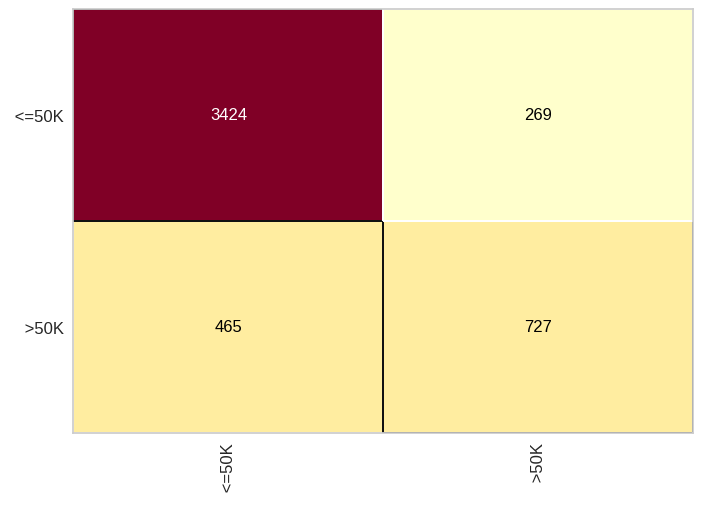

In [41]:
from yellowbrick.classifier import ConfusionMatrix
cm_credit = ConfusionMatrix(regressao_census)
cm_credit.fit(X_census_trainamento, Y_census_trainamento)
cm_credit.score(X_census_teste, Y_census_teste)

In [42]:
print(classification_report(Y_census_teste, previsores_regressao))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline SVM | Digest [Fase 6 - Census Base]

In [43]:
from sklearn.svm import SVC

In [44]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_trainamento, Y_census_trainamento)

SVC(C=2.0, random_state=1)

In [45]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [46]:
svm_previsoes = svm_census.predict(X_census_teste)
svm_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [47]:
accuracy_score(Y_census_teste, svm_previsoes)

0.8485158648925282

0.8485158648925282

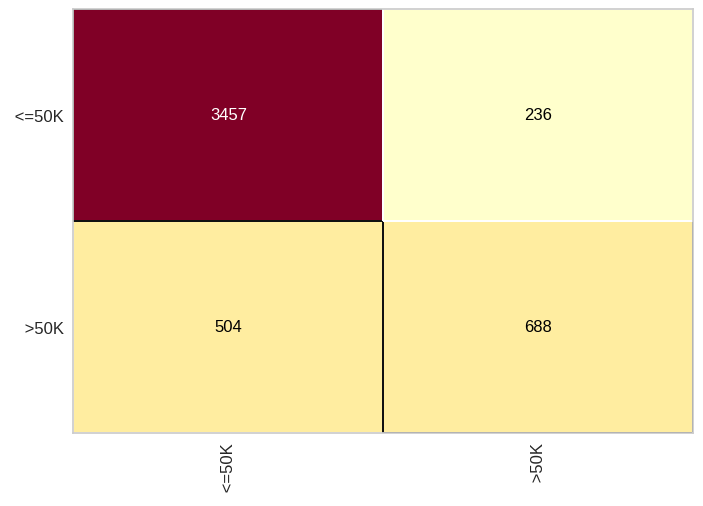

In [48]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_trainamento, Y_census_trainamento)
svm_cm.score(X_census_teste, Y_census_teste)

# Pipeline Redes Neurais | Digest [Fase 7 - Census Base]

In [49]:
from sklearn.neural_network import MLPClassifier

In [50]:
redeneural_census = MLPClassifier(verbose = True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_census.fit(X_census_trainamento, Y_census_trainamento)

Iteration 1, loss = 0.38390262
Iteration 2, loss = 0.32626133
Iteration 3, loss = 0.31567283
Iteration 4, loss = 0.30945680
Iteration 5, loss = 0.30439790
Iteration 6, loss = 0.30075314
Iteration 7, loss = 0.29794611
Iteration 8, loss = 0.29555427
Iteration 9, loss = 0.29351028
Iteration 10, loss = 0.29089556
Iteration 11, loss = 0.28919440
Iteration 12, loss = 0.28766053
Iteration 13, loss = 0.28634194
Iteration 14, loss = 0.28478517
Iteration 15, loss = 0.28362450
Iteration 16, loss = 0.28216786
Iteration 17, loss = 0.28115176
Iteration 18, loss = 0.27963333
Iteration 19, loss = 0.27825467
Iteration 20, loss = 0.27716025
Iteration 21, loss = 0.27600056
Iteration 22, loss = 0.27474273
Iteration 23, loss = 0.27391665
Iteration 24, loss = 0.27316346
Iteration 25, loss = 0.27210729
Iteration 26, loss = 0.27146632
Iteration 27, loss = 0.26989997
Iteration 28, loss = 0.26933807
Iteration 29, loss = 0.26797658
Iteration 30, loss = 0.26808139
Iteration 31, loss = 0.26649781
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [51]:
redeneural_census.out_activation_

'logistic'

In [52]:
previsoes_redeneural = redeneural_census.predict(X_census_teste)
previsoes_redeneural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [53]:
accuracy_score(Y_census_teste, previsoes_redeneural)

0.822517911975435

0.822517911975435

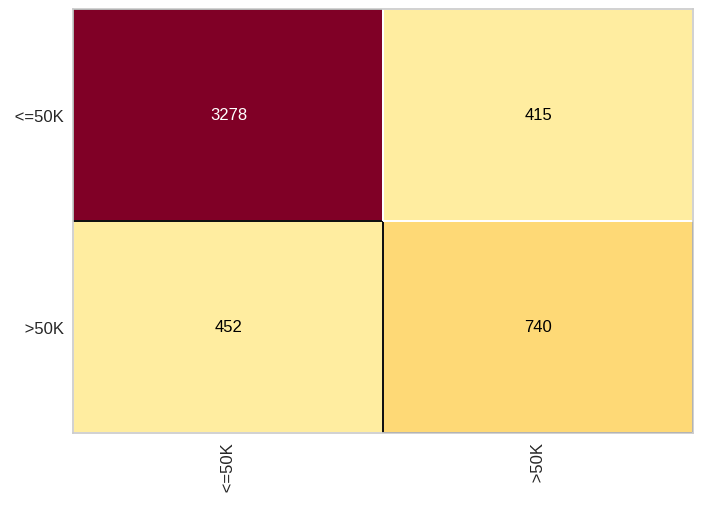

In [54]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_trainamento, Y_census_trainamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [55]:
print(classification_report(Y_census_teste, previsoes_redeneural))

              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.88      3693
        >50K       0.64      0.62      0.63      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.75      0.76      4885
weighted avg       0.82      0.82      0.82      4885



# Pipeline Preparação de dados - KNN | Digest [Fase 8 - Census Base]

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
scaler = StandardScaler()

In [58]:
X_train_knn = scaler.fit_transform(X_census_trainamento)
X_test_knn = scaler.transform(X_census_teste)

In [59]:
le = LabelEncoder()

In [60]:
Y_train_knn = le.fit_transform(Y_census_trainamento)
Y_test_knn = le.transform(Y_census_teste)

In [61]:
parametros = {
    'n_neighbors': [3, 5, 10, 20],
    'p': [1, 2]
}

In [62]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros, cv=5, n_jobs=-1)
grid_census.fit(X_train_knn, Y_train_knn)
print("Melhores parâmetros:", grid_census.best_params_)
print("Melhor score:", grid_census.best_score_)

Melhores parâmetros: {'n_neighbors': 20, 'p': 1}
Melhor score: 0.8329959506242461


In [63]:
knn_census = KNeighborsClassifier(n_neighbors=grid_census.best_params_['n_neighbors'], p=grid_census.best_params_['p'])
knn_census.fit(X_train_knn, Y_train_knn)

KNeighborsClassifier(n_neighbors=20, p=1)

In [64]:
previsoes_knn = knn_census.predict(X_test_knn)

In [65]:
print("Acurácia:", accuracy_score(Y_test_knn, previsoes_knn))

print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test_knn, previsoes_knn))

print("\nRelatório de Classificação:")
print(classification_report(Y_test_knn, previsoes_knn))

Acurácia: 0.8296827021494371

Matriz de Confusão:
[[3427  266]
 [ 566  626]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      3693
           1       0.70      0.53      0.60      1192

    accuracy                           0.83      4885
   macro avg       0.78      0.73      0.75      4885
weighted avg       0.82      0.83      0.82      4885

